# Analiza KajoDATA
Notebook przedstawia proces przetwarzania surowych danych. Chciałem tu ukazać co kryje się "pod maską" skryptu oraz wytłumaczyć kilka moich założeń zwiazanych z mapowaniem czy przynależnościa do odpowienich kohort.

### Import bibliotek

In [1]:
import pandas as pd
import os
import logging
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

### Funkcje pomocnicze 

In [2]:
def assign_period(date):
    if date < pd.Timestamp(2024, 6, 1): return "1. Początek"
    if date < pd.Timestamp(2024, 10, 1): return "2. Dane zakłamane"
    if date < pd.Timestamp(2025, 12, 1): return "3. Wzrost"
    return "4. Najnowsze"

def get_range(row):
    start_date = row['Data transakcji']
    plan = row['Czas dostępu']
    months_count = {'Miesiąc': 1, 'Rok': 12, '2 Lata': 24}.get(plan, 1)
    start_period = start_date.to_period('M')
    return [start_period + i for i in range(months_count)]

def check_if_returned(row):
    active = row[row == 1].index
    if len(active) < 2: return 0 
    if 0 in row.loc[active[0]:active[-1]].values: return 1
    return 0

def subscription_time(row):
    offsets = {
        'Miesiąc': pd.DateOffset(months=1),
        'Rok':     pd.DateOffset(years=1),
        '2 Lata':  pd.DateOffset(years=2)}
    offset = offsets.get(row['Czas dostępu'])
    return row['Data transakcji'] + offset if offset else row['Data transakcji']

def get_trend(f, l, n):
    if n == 1: return 'Stabilne'
    if l > f:  return 'Upgrade'
    if l < f:  return 'Downgrade' 
    return 'Mieszany' 

### Konfiguracja środowiska i ścieżek

Pisząc kod zawierajacy wykresy pamiętaj o 12% mężczyzn którzy nie zobaczą części kolorow. slatego warto dodać "sns.set_palette("colorblind")"

In [3]:
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.2f' % x) 
sns.set_palette("colorblind")
sns.set_style("whitegrid")

PROJECT_ROOT = ".."
RAW_PATH = os.path.join(PROJECT_ROOT, "Raw", "KDS Transactions.xlsx")
MAP_PATH = "price_mapping.csv"
OUTPUT_DIR = os.path.join(PROJECT_ROOT, "Output")

if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)

print(f"Pliki zostaną zapisane w: {os.path.abspath(OUTPUT_DIR)}")

Pliki zostaną zapisane w: c:\Users\www\Desktop\programowanie\Kurs\PRACE-DODATKOWE\KajoDATA\Output


### 1. Wczytywanie i czyszczenie danych

#### Wstępna analiza zestawu dancych.

In [5]:
df_raw = pd.read_excel(RAW_PATH, usecols=['Data transakcji', 'Klient', 'Kwota'])
df = df_raw.copy()

<Axes: >

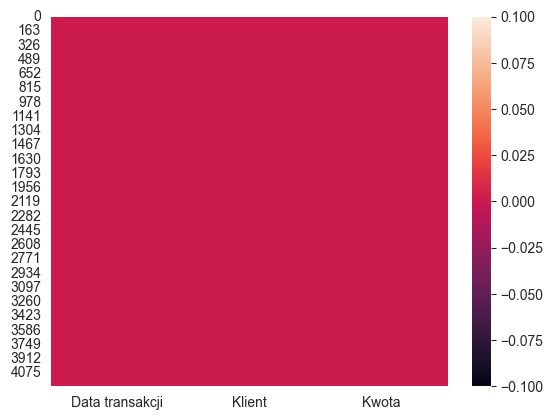

In [6]:
sns.heatmap(df.isnull())

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4227 entries, 0 to 4226
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Data transakcji  4227 non-null   datetime64[us]
 1   Klient           4227 non-null   int64         
 2   Kwota            4227 non-null   float64       
dtypes: datetime64[us](1), float64(1), int64(1)
memory usage: 99.2 KB


In [8]:
df.describe()

,Data transakcji,Klient,Kwota
count,4227,4227.00,4227.00
mean,2025-04-24 20:49:36.309527,398.85,246.63
min,2023-11-05 18:04:23.495000,1.00,35.60
25%,2024-11-08 10:41:55.631500,170.00,99.00
50%,2025-05-30 16:43:19.121000,322.00,169.00
75%,2025-11-08 17:59:05.758000,626.00,199.00
max,2026-03-31 19:50:38.809000,1057.00,2089.05
std,NaN,285.88,311.83


Ze wstępnej analizy wynika że dane są kompletne, typy nie są pomieszane a dane wydają się być logiczne. Nie ma sztucznie zapełnionych rekordów np Kwota = 0, nie ma też dziwnych dat którymi należało by się martwić.

Mimo że konkursowy zestaw dancy wydaje się być ok, chciałem to zautomatyzować, bo następny zestaw może mieć jakieś błędy.

In [9]:

df['Data transakcji'] = pd.to_datetime(df['Data transakcji'])
df = df.dropna(subset=['Klient', 'Data transakcji', 'Kwota'])
df = df.sort_values(['Klient', 'Data transakcji']).reset_index(drop=True)
df.head()

,Data transakcji,Klient,Kwota
0,2023-11-05 18:04:23.495,1,35.60
1,2023-11-05 18:18:50.352,2,89.00
2,2023-11-05 20:49:31.816,2,356.31
3,2024-05-05 22:50:21.486,2,445.00
4,2024-11-05 21:51:13.699,2,445.00


### 2. Mapowanie cen i trworzenie metryk


Mapowanie cen jest wykonane na podstawie tabeli którą stworzyłem ręcznie przypisując każdej kwocie dwie wartości. Pierwszą jest czas subskrypcji miesiąc / rok / 2 lata, a drugą jest zakres subskrypcji kurs/wszystko. Z powodu bardzo dużych rozpiętości cenowych nie dało się tego zrobić w formie skryptu np ceny miesięcznej subskrypcji wachają się od 40 do prawie 300 zł, a koszty kursów rocznych od 150 do 700. Dlatego przeanalizowałem odstępy w płatnościach między poszczególnymi cenami oraz poszukałem informacji o promocjach na YT, FB oraz discordzie i na tej podstawie zrobiłem mapowanie. Gdybym dostał konkretną listę cen promocyjnych lub okresów ich występowania wystarczy zmienić to w tabelce i odpalić skrypt. Jednocześnie należy podkreślić że z pewnością popełniłem błędy np cena 199 oraz 249 obejmuje kursy roczne oraz subskrypcje, ja zakwalifikowałem je jednak jako subskrypcje ponieważ ich w tej cenie było po prostu wielokrotnie więcej. Dodatkowo muszę zaznaczyć że mimo iż przypisałem cenom wartość kurs/ subskrypcja nie wykorzystałem tego w kodzie, ponieważ tutaj błędów mogło byś znacznie więcej. 

In [10]:
if os.path.exists(MAP_PATH):
    price_map = pd.read_csv(MAP_PATH, sep=';', decimal=',', encoding='utf-8-sig')
    price_map = price_map.drop_duplicates(subset='Kwota')
    df = pd.merge(df, price_map, on='Kwota', how='left')

Tworzenie dodatkowych metryk na podstawie 3 kolumn

In [11]:


df['Pierwsza płatność'] = df.groupby('Klient')['Data transakcji'].transform('min').dt.normalize()
df['Ostatnia płatność'] = df.groupby('Klient')['Data transakcji'].transform('max').dt.normalize()
df['Kohorta'] = df['Pierwsza płatność'].dt.to_period('M')
df['Grupa Kohort'] = df['Pierwsza płatność'].apply(assign_period)
df['Nr Transakcji'] = df.groupby('Klient').cumcount() + 1

rank = df['Czas dostępu'].map({'Miesiąc': 1, 'Rok': 2, '2 Lata': 3})
first_rank = rank.groupby(df['Klient']).transform('first')
last_rank = rank.groupby(df['Klient']).transform('last')
n_unique = rank.groupby(df['Klient']).transform('nunique')
df['Zmiana planu'] = [get_trend(f, l, n) for f, l, n in zip(first_rank, last_rank, n_unique)]

df['Koniec subskrypcji'] = df.apply(subscription_time, axis=1).dt.normalize()
max_date = df['Data transakcji'].max()
df['Status_Sub'] = df['Koniec subskrypcji'].apply(lambda x: 'Aktywny' if x >= max_date else 'Wygasły')
df['LTV Narastajaco'] = df.groupby('Klient')['Kwota'].cumsum().round(2)
df['Wiek_Msc'] = (df['Data transakcji'].dt.year - df['Pierwsza płatność'].dt.year) * 12 + (df['Data transakcji'].dt.month - df['Pierwsza płatność'].dt.month)

df.head()

,Data transakcji,Klient,Kwota,Typ dostępu,Czas dostępu,Pierwsza płatność,Ostatnia płatność,Kohorta,Grupa Kohort,Nr Transakcji,Zmiana planu,Koniec subskrypcji,Status_Sub,LTV Narastajaco,Wiek_Msc
0,2023-11-05 18:04:23.495,1,35.60,Kurs,Miesiąc,2023-11-05,2023-11-05,2023-11,1. Początek,1,Stabilne,2023-12-05,Wygasły,35.60,0
1,2023-11-05 18:18:50.352,2,89.00,Całość,Miesiąc,2023-11-05,2024-11-05,2023-11,1. Początek,1,Upgrade,2023-12-05,Wygasły,89.00,0
2,2023-11-05 20:49:31.816,2,356.31,Kurs,Rok,2023-11-05,2024-11-05,2023-11,1. Początek,2,Upgrade,2024-11-05,Wygasły,445.31,0
3,2024-05-05 22:50:21.486,2,445.00,Kurs,Rok,2023-11-05,2024-11-05,2023-11,1. Początek,3,Upgrade,2025-05-05,Wygasły,890.31,6
4,2024-11-05 21:51:13.699,2,445.00,Kurs,Rok,2023-11-05,2024-11-05,2023-11,1. Początek,4,Upgrade,2025-11-05,Wygasły,1335.31,12


### 3. Tworzenie szerokiej macierzy retencji

In [12]:
client_metrics = df.groupby('Klient').agg({
    'Pierwsza płatność': 'first', 'Ostatnia płatność': 'last', 'Kohorta': 'first',
    'Grupa Kohort': 'first', 'Czas dostępu': 'first', 'Zmiana planu': 'first',
    'Status_Sub': 'last', 'Kwota': 'sum'
}).rename(columns={'Kwota': 'LTV_Total'})

matrix_df = df[['Klient']].assign(M=df.apply(get_range, axis=1)).explode('M')
matrix = matrix_df.pivot_table(index='Klient', columns='M', aggfunc='size', fill_value=0)
matrix = (matrix > 0).astype(int)
current_month = df['Data transakcji'].max().to_period('M')
matrix = matrix.loc[:, :current_month]

matrix['Suma_Miesiecy'] = matrix.sum(axis=1)
matrix['Wrocil'] = matrix.drop(columns=['Suma_Miesiecy']).apply(check_if_returned, axis=1)

is_decimal = df.groupby('Klient')['Kwota'].apply(lambda x: any(v % 1 > 0.001 for v in x))
matrix['Typ_Ceny'] = matrix.index.map(is_decimal).map({True: 'Promocyjna', False: 'Standardowa'})
matrix['Staly_Klient'] = (matrix['Suma_Miesiecy'] >= 13).astype(int).map({1: 'Tak', 0: 'Nie'})
matrix = matrix.join(client_metrics)

cohort_data = matrix.copy()
matrix.head()

,2023-11,2023-12,2024-01,2024-02,2024-03,2024-04,2024-05,2024-06,2024-07,2024-08,2024-09,2024-10,2024-11,2024-12,2025-01,2025-02,2025-03,2025-04,2025-05,2025-06,2025-07,2025-08,2025-09,2025-10,2025-11,2025-12,2026-01,2026-02,2026-03,Suma_Miesiecy,Wrocil,Typ_Ceny,Staly_Klient,Pierwsza płatność,Ostatnia płatność,Kohorta,Grupa Kohort,Czas dostępu,Zmiana planu,Status_Sub,LTV_Total
Klient,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,Promocyjna,Nie,2023-11-05,2023-11-05,2023-11,1. Początek,Miesiąc,Stabilne,Wygasły,35.60
2,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0,0,0,0,24,0,Promocyjna,Tak,2023-11-05,2024-11-05,2023-11,1. Początek,Miesiąc,Upgrade,Wygasły,1335.31
3,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,29,0,Promocyjna,Tak,2023-11-05,2025-11-05,2023-11,1. Początek,Rok,Stabilne,Aktywny,1891.25
4,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,4,0,Promocyjna,Nie,2023-11-05,2024-02-05,2023-11,1. Początek,Miesiąc,Stabilne,Wygasły,302.60
5,1,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,8,0,Promocyjna,Nie,2023-11-05,2024-06-05,2023-11,1. Początek,Miesiąc,Stabilne,Wygasły,605.20


### 4. Tworzenie długiej tabela retencji.

Ten format zdecydowanie lepiej nadaje się do tworzenia tabel przestawnych w exelu niż formal szeroki.

In [13]:
metadata_cols = [
    'Klient', 'Kohorta', 'Grupa Kohort', 'Czas dostępu', 'Suma_Miesiecy', 
    'Wrocil', 'Pierwsza płatność', 'Ostatnia płatność', 'Zmiana planu', 
    'Status_Sub', 'LTV_Total', 'Typ_Ceny', 'Staly_Klient'
]

long_retention = cohort_data.reset_index().melt(id_vars=metadata_cols, var_name='Data_Miesiac', value_name='Aktywny')
long_retention['Data_Miesiac'] = pd.PeriodIndex(long_retention['Data_Miesiac'], freq='M')
long_retention['Miesiac_Relatywny'] = (long_retention['Data_Miesiac'] - long_retention['Kohorta']).apply(lambda x: x.n)
long_retention = long_retention[long_retention['Miesiac_Relatywny'] >= 0]

long_retention.head()

,Klient,Kohorta,Grupa Kohort,Czas dostępu,Suma_Miesiecy,Wrocil,Pierwsza płatność,Ostatnia płatność,Zmiana planu,Status_Sub,LTV_Total,Typ_Ceny,Staly_Klient,Data_Miesiac,Aktywny,Miesiac_Relatywny
0,1,2023-11,1. Początek,Miesiąc,1,0,2023-11-05,2023-11-05,Stabilne,Wygasły,35.60,Promocyjna,Nie,2023-11,1,0
1,2,2023-11,1. Początek,Miesiąc,24,0,2023-11-05,2024-11-05,Upgrade,Wygasły,1335.31,Promocyjna,Tak,2023-11,1,0
2,3,2023-11,1. Początek,Rok,29,0,2023-11-05,2025-11-05,Stabilne,Aktywny,1891.25,Promocyjna,Tak,2023-11,1,0
3,4,2023-11,1. Początek,Miesiąc,4,0,2023-11-05,2024-02-05,Stabilne,Wygasły,302.60,Promocyjna,Nie,2023-11,1,0
4,5,2023-11,1. Początek,Miesiąc,8,0,2023-11-05,2024-06-05,Stabilne,Wygasły,605.20,Promocyjna,Nie,2023-11,1,0


### 5. Eksport wyników do CSV

In [ ]:
df_matrix_export = matrix.copy()
df_matrix_export['Kohorta'] = df_matrix_export['Kohorta'].dt.strftime('%m.%Y')

df_long_export = long_retention.copy()
df_long_export['Kohorta'] = df_long_export['Kohorta'].dt.strftime('%m.%Y')

final_columns_main = ['Data transakcji', 'Klient', 'Kwota', 'Nr Transakcji', 'Wiek_Msc', 'LTV Narastajaco']

df[final_columns_main].to_csv(os.path.join(OUTPUT_DIR, "KDS_Cleaned_Transactions.csv"), sep=';', index=False, encoding='utf-8-sig', decimal=',')
df_matrix_export.to_csv(os.path.join(OUTPUT_DIR, "KDS_Matrix.csv"), sep=';', encoding='utf-8-sig', decimal=',')
df_long_export.to_csv(os.path.join(OUTPUT_DIR, "KDS_Long_Retention.csv"), sep=';', index=False, encoding='utf-8-sig', decimal=',')

print("Eksport zakończony pomyślnie!")

Eksport zakończony pomyślnie!


### 6. Wizualizacja: Heatmapa Retencji (%)

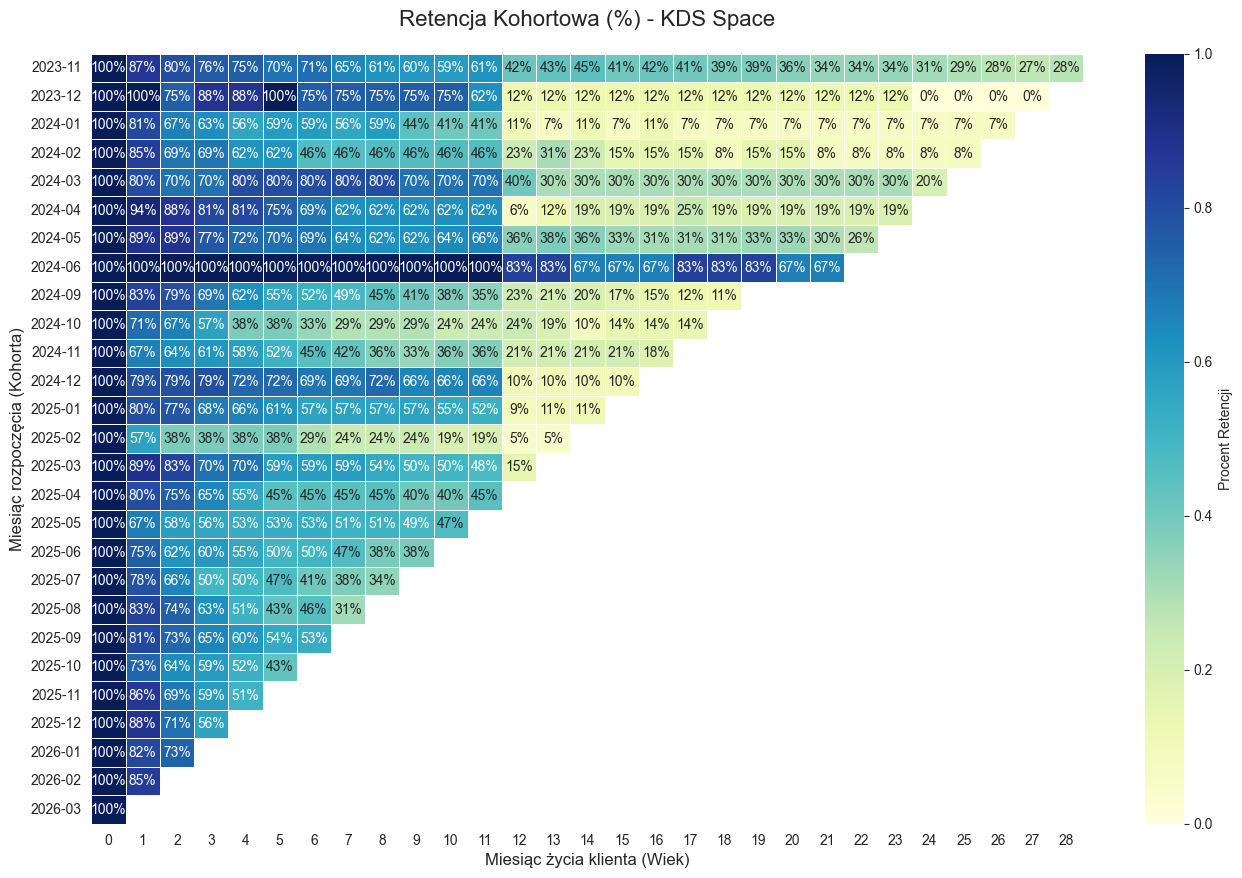

In [ ]:
cohort_pivot = long_retention.groupby(['Kohorta', 'Miesiac_Relatywny'])['Aktywny'].sum().unstack()
cohort_sizes = cohort_pivot.iloc[:, 0]
retention_pct = cohort_pivot.divide(cohort_sizes, axis=0)

# 2. Rysowanie heatmapy
plt.figure(figsize=(16, 10))
sns.set_style("white")
sns.heatmap(retention_pct, 
            annot=True, 
            fmt='.0%', 
            cmap='YlGnBu', 
            vmin=0, 
            vmax=1, 
            linewidths=.5,
            cbar_kws={'label': 'Procent Retencji'})

plt.title('Retencja Kohortowa (%) - KDS Space', fontsize=16, pad=20)
plt.ylabel('Miesiąc rozpoczęcia (Kohorta)', fontsize=12)
plt.xlabel('Miesiąc życia klienta (Wiek)', fontsize=12)
plt.show()

Na heatmapie widać kilka anormalnych obszarów, udało mi się wyjaśnić powody zachowania większości "dziwnych" kohort. 
11-12.2023 start kanału i efekt fanów którzy czekali na start kanału
06-08.2024 w tym okresie sprzedaż była zamknięta oprócz kilku osób w 06.2024 którym możliwość zakupu dał bezpośrednio wlaściciel.
09.2024 skumulowany popyt spowodowany zablokowaniem sprzedaży


### 7. Analiza Przeżywalności (Survival Analysis)

Poniższy wykres pokazuje prawdopodobieństwo pozostania klienta w bazie w zależności od tego, czy kupił produkt w cenie standardowej czy promocyjnej. Zastosowałem prosty wskaźnik cen promocyjnych jako kwoty które mają grosze, jest to obraz niepełny ponieważ wielokrotnie ceny promocyjne były pełne, jednak nawet w tej okrojonej wersji można zauważyć pewne ciekawe zjawisko.  

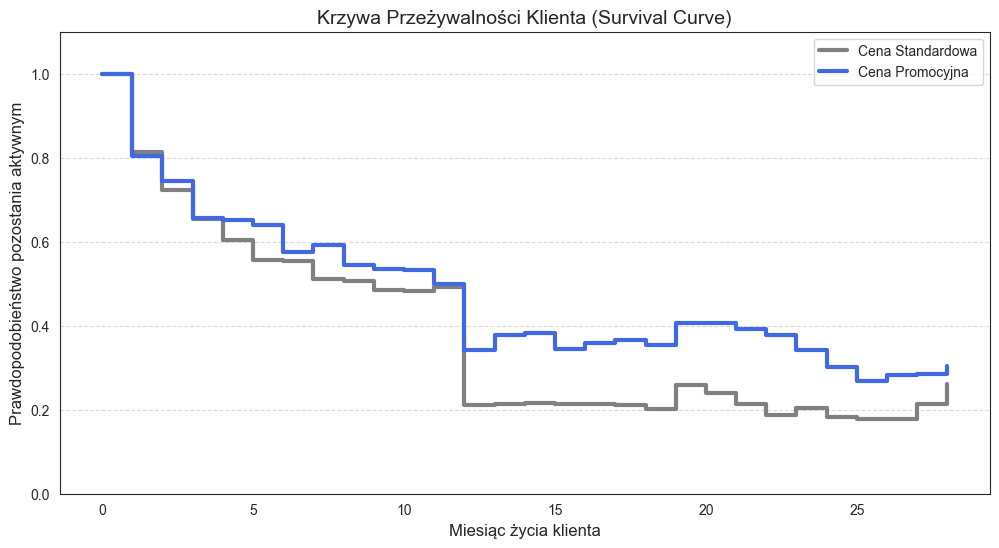

In [17]:
# Obliczanie średniej retencji dla grup cenowych
survival_data = long_retention.groupby(['Typ_Ceny', 'Miesiac_Relatywny'])['Aktywny'].mean().unstack().T

plt.figure(figsize=(12, 6))
plt.step(survival_data.index, survival_data['Standardowa'], label='Cena Standardowa', where='post', lw=3, color='grey')
plt.step(survival_data.index, survival_data['Promocyjna'], label='Cena Promocyjna', where='post', lw=3, color='royalblue')

plt.title('Krzywa Przeżywalności Klienta (Survival Curve)', fontsize=14)
plt.xlabel('Miesiąc życia klienta', fontsize=12)
plt.ylabel('Prawdopodobieństwo pozostania aktywnym', fontsize=12)
plt.ylim(0, 1.1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()
plt.show()

Jak widać przez cały okres życia użytkownika przeżywalność użytkowników promocyjnych jest większa od standardowych. Sądzę że pełne dane dotyczące sprzedaży potwierdziłyby tę obserwację. 

Tutaj chciałbym zakończyć wstępną analizę by nie powielać wykresów z docelowym dashboardem. 